# 03e — DINOv3 vs CLIP vs SigLIP — the model comparison

**Phase 1.5, notebook 5 of 5 — the capstone.**

Until now we've measured *one* model. We can't say *"DINOv3 is good"* without saying *"good compared to what?"* — that's the question this notebook finally answers. We'll embed the same 205 photos with three models, run the same two eval tasks against each, and see how they rank.

By the end you will:
1. Be able to **explain the three training paradigms** in one sentence each: SSL (DINOv3), softmax-contrastive (CLIP), sigmoid-contrastive (SigLIP).
2. Have a **comparison table with bootstrap CIs** you can put directly in your CV / portfolio.
3. Know how to read **crossings** in Recall@k curves — when one model wins low-k and another wins high-k, what does that mean about each one's geometry?
4. Understand which model LUKI should ship and **why** — defensible in 30 seconds.

---

## Refresher — the three training paradigms in one slide

All three are vision encoders that produce dense embeddings, but they were trained for different objectives, on different data, and with different losses. Those choices imprint on the embedding geometry — and the embedding geometry is what we're comparing.

| | **DINOv3** | **CLIP** | **SigLIP** |
|---|---|---|---|
| Family | Self-supervised | Contrastive image-text | Contrastive image-text |
| Loss | DINO student-teacher distillation, no labels | Softmax cross-entropy over batch | Sigmoid binary classification per pair |
| Data signal | Augmented views of the *same image* | Image + caption pairs from the web | Image + caption pairs from the web |
| What it optimises | *"Augmentations of the same image embed near each other"* | *"Image embeds near its caption, far from other captions"* | *"For each (image, caption) pair, predict whether they match"* |
| Inductive bias | Visual structure (texture, geometry, scenes) | Semantic content (objects, names, descriptions) | Same as CLIP, but more stable at scale |
| Embedding dim | 1024 | 512 | 768 |

**One-liner difference**: DINOv3 learns *what's in the pixels*; CLIP/SigLIP learn *what humans say is in the pixels*. The same photo of a beach: DINOv3 encodes "sandy texture, blue gradient, horizon line"; CLIP encodes "beach." Different priors → different rankings → different downstream performance.

**Why SigLIP exists**: CLIP's softmax loss couples each image's gradient to *every other image in the batch* — at scale this becomes numerically unstable and memory-bound. SigLIP replaces softmax with per-pair sigmoid, breaking the coupling. Cleaner gradient, better scaling, marginally different geometry.

**Cosine still works for all three.** All three models output L2-normalised vectors (or vectors we can normalise after). Cosine similarity for retrieval makes sense regardless of training loss. *That's defensible* — interviewers will ask, and the answer is *"the loss shaped the embedding space; the metric is just how I measure distance in it."*

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO = Path().resolve().parent
sys.path.insert(0, str(REPO / "src"))

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image

from luki.api import services
from luki.embeddings.dataset import load_image, resolve_path
from luki.eval.augment import DEFAULT_AUGMENTATIONS
from luki.eval.queries import build_holdout_task, stratified_sample
from luki.eval.runner import evaluate_holdout
from luki.eval.metrics import (
    average_precision, bootstrap_ci, precision_at_k,
    recall_at_k, reciprocal_rank,
)

manifest = pd.read_parquet(REPO / "data" / "processed" / "manifest.parquet")
RAW_DIR  = REPO / "data" / "raw"
EMBED_CACHE_DIR = REPO / "data" / "processed" / "eval_embeddings"
EMBED_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"{len(manifest)} photos, cache dir: {EMBED_CACHE_DIR}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")

c:\winhome\dev\luki\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


205 photos, cache dir: C:\winhome\dev\luki\data\processed\eval_embeddings
device: cpu


## Loading the models

Three encoders, all from `transformers`:

- **DINOv3-ViT-L/16** — 1024-dim, 303M params (already loaded by LUKI's API service singleton).
- **CLIP-ViT-B/32** — 512-dim, ~150M image-encoder params. The classic baseline.
- **SigLIP-base-patch16-224** — 768-dim, ~200M image-encoder params.

Memory note: loading all three on CPU costs ~2.5GB of RAM. If you're tight, embed → cache → free, one at a time.

In [2]:
from transformers import CLIPModel, CLIPImageProcessor, SiglipModel, SiglipImageProcessor

def embed_with_clip(images: list[Image.Image]) -> np.ndarray:
    proc = CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch32")
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
    out = []
    BATCH = 8
    with torch.inference_mode():
        for i in range(0, len(images), BATCH):
            batch = images[i:i+BATCH]
            inputs = proc(images=batch, return_tensors="pt").to(DEVICE)
            # transformers ≥5: get_image_features returns BaseModelOutputWithPooling
            feats = model.get_image_features(**inputs).pooler_output
            feats = torch.nn.functional.normalize(feats, dim=-1)
            out.append(feats.cpu().numpy())
    return np.concatenate(out, axis=0)

def embed_with_siglip(images: list[Image.Image]) -> np.ndarray:
    # Image-only processor avoids the SentencePiece dependency that the full SiglipProcessor pulls in.
    proc = SiglipImageProcessor.from_pretrained("google/siglip-base-patch16-224")
    model = SiglipModel.from_pretrained("google/siglip-base-patch16-224").to(DEVICE).eval()
    out = []
    BATCH = 8
    with torch.inference_mode():
        for i in range(0, len(images), BATCH):
            batch = images[i:i+BATCH]
            inputs = proc(images=batch, return_tensors="pt").to(DEVICE)
            feats = model.get_image_features(**inputs).pooler_output
            feats = torch.nn.functional.normalize(feats, dim=-1)
            out.append(feats.cpu().numpy())
    return np.concatenate(out, axis=0)

print("Embedder functions defined. Models will download on first run.")

Embedder functions defined. Models will download on first run.


## Embedding the corpus — once per model, then cached

First-run cost on CPU: roughly 2-3 minutes per model for 205 photos. We cache the resulting matrix to disk so re-runs of the notebook skip the recompute.

In [3]:
def embed_or_load(name: str, embed_fn) -> np.ndarray:
    """Embed the full corpus with `embed_fn` if no cache exists; otherwise load.

    Returns a (N, D) L2-normalised float32 matrix, in manifest row order.
    """
    cache_path = EMBED_CACHE_DIR / f"{name}.npy"
    if cache_path.exists():
        print(f"  [{name}] loading from cache: {cache_path.name}")
        return np.load(cache_path)
    print(f"  [{name}] embedding {len(manifest)} photos — first run takes a few minutes…")
    images = [load_image(resolve_path(p, RAW_DIR)) for p in manifest["relative_path"]]
    t0 = time.time()
    vecs = embed_fn(images).astype(np.float32)
    print(f"  [{name}] done in {time.time()-t0:.1f}s, shape={vecs.shape}")
    np.save(cache_path, vecs)
    return vecs

# DINOv3 — pull from Qdrant (already embedded). Reorder to manifest order.
def load_dino_from_qdrant() -> np.ndarray:
    store = services.get_store()
    pts, _ = store.client.scroll(
        collection_name=store.collection_name, limit=500,
        with_payload=True, with_vectors=True,
    )
    by_path = {p.payload["relative_path"]: np.array(p.vector) for p in pts}
    return np.stack([by_path[p] for p in manifest["relative_path"]]).astype(np.float32)

embeddings = {
    "dinov3": embed_or_load("dinov3", lambda imgs: load_dino_from_qdrant()),
    "clip":   embed_or_load("clip",   embed_with_clip),
    "siglip": embed_or_load("siglip", embed_with_siglip),
}
for name, v in embeddings.items():
    norm_min, norm_max = np.linalg.norm(v, axis=1).min(), np.linalg.norm(v, axis=1).max()
    print(f"{name:8s}: shape={v.shape}  norms in [{norm_min:.3f}, {norm_max:.3f}]")

  [dinov3] loading from cache: dinov3.npy
  [clip] loading from cache: clip.npy
  [siglip] loading from cache: siglip.npy
dinov3  : shape=(205, 1024)  norms in [1.000, 1.000]
clip    : shape=(205, 512)  norms in [1.000, 1.000]
siglip  : shape=(205, 768)  norms in [1.000, 1.000]


## Task 1 — roll hold-out (Family A)

Same task as `03d`, now run for all three models against the same eval set.

In [4]:
eval_set = build_holdout_task(manifest, group_col="roll_tags", min_group_size=3)
print(f"Hold-out eval set: {len(eval_set)} queries (digital cohort excluded — no roll metadata)")

holdout_results = {}
for name, vecs in embeddings.items():
    holdout_results[name] = evaluate_holdout(
        eval_set=eval_set,
        embeddings=vecs,
        corpus_paths=manifest["relative_path"].tolist(),
        corpus_manifest=manifest,
        group_col="roll_tags",
        top_k=50,
    )
    print(f"  {name:8s}: evaluated {len(holdout_results[name])} queries")

Hold-out eval set: 186 queries (digital cohort excluded — no roll metadata)
  dinov3  : evaluated 186 queries
  clip    : evaluated 186 queries
  siglip  : evaluated 186 queries


In [5]:
# Headline holdout table with bootstrap CIs
rows = []
for name, df in holdout_results.items():
    row = {"model": name}
    for col in ["Recall@10", "Recall@20", "P@10", "RR", "AP"]:
        m, lo, hi = bootstrap_ci(df[col].to_numpy())
        row[col] = f"{m:.3f} [{lo:.2f}, {hi:.2f}]"
    rows.append(row)
holdout_summary = pd.DataFrame(rows).set_index("model")
holdout_summary

,Recall@10,Recall@20,P@10,RR,AP
model,,,,,
dinov3,"0.116 [0.11, 0.12]","0.186 [0.17, 0.20]","0.421 [0.39, 0.45]","0.831 [0.78, 0.87]","0.180 [0.17, 0.19]"
clip,"0.136 [0.13, 0.14]","0.223 [0.21, 0.24]","0.495 [0.47, 0.52]","0.867 [0.83, 0.91]","0.219 [0.20, 0.23]"
siglip,"0.132 [0.12, 0.14]","0.216 [0.20, 0.23]","0.476 [0.45, 0.51]","0.873 [0.83, 0.91]","0.219 [0.20, 0.24]"


## Task 2 — augmentation invariance (Family B)

From `03c`. We embed the augmented query at runtime (model-specific encoder), then score against the corpus matrix for that model.

In [6]:
from luki.eval.queries import build_augmentation_task

aug_set = build_augmentation_task(manifest, n_per_group=8, seed=42)
print(f"Augmentation eval set: {len(aug_set)} queries × {len(DEFAULT_AUGMENTATIONS)} augmentations")

def evaluate_augmentation_against(
    eval_set: pd.DataFrame,
    embed_query_fn,
    corpus_embeddings: np.ndarray,
    corpus_paths: list[str],
    seed: int = 42,
) -> pd.DataFrame:
    """Score augmentation invariance using a model-specific query encoder."""
    path_to_idx = {p: i for i, p in enumerate(corpus_paths)}
    rows = []
    for aug_name, aug_fn in DEFAULT_AUGMENTATIONS.items():
        rng = np.random.default_rng(seed)
        for _, q in eval_set.iterrows():
            original = load_image(resolve_path(q["relative_path"], RAW_DIR))
            aug_img = aug_fn(original, rng)
            qvec = embed_query_fn([aug_img])[0]
            qvec = qvec / (np.linalg.norm(qvec) + 1e-12)
            sims = corpus_embeddings @ qvec
            order = np.argsort(-sims)
            top = [corpus_paths[i] for i in order[:20]]
            target_idx = path_to_idx[q["relative_path"]]
            target_path = corpus_paths[target_idx]
            rank = top.index(target_path) + 1 if target_path in top else None
            rows.append({
                "aug": aug_name, "medium": q["medium"], "roll_tags": q["roll_tags"],
                "rank": rank,
                "recall@1": 1.0 if rank == 1 else 0.0,
                "rr": 1.0 / rank if rank else 0.0,
            })
    return pd.DataFrame(rows)

Augmentation eval set: 48 queries × 4 augmentations


In [7]:
# Per-model query encoders (used inside the augmentation eval to embed the augmented query)
def _dino_embed(imgs):
    return services.get_embedder().embed(imgs)

embed_fns = {
    "dinov3": _dino_embed,
    "clip":   embed_with_clip,
    "siglip": embed_with_siglip,
}

aug_results = {}
for name in ["dinov3", "clip", "siglip"]:
    print(f"  [{name}] running augmentation eval ({len(aug_set)*len(DEFAULT_AUGMENTATIONS)} evaluations)…")
    t0 = time.time()
    aug_results[name] = evaluate_augmentation_against(
        aug_set, embed_fns[name], embeddings[name],
        manifest["relative_path"].tolist(),
    )
    print(f"  [{name}] done in {time.time()-t0:.1f}s")

  [dinov3] running augmentation eval (192 evaluations)…


Loading weights: 100%|██████████| 415/415 [00:00<00:00, 5612.33it/s]


  [dinov3] done in 123.1s
  [clip] running augmentation eval (192 evaluations)…


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 55232.03it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 32024.96it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 

  [clip] done in 306.3s
  [siglip] running augmentation eval (192 evaluations)…


Loading weights: 100%|██████████| 408/408 [00:00<00:00, 7608.34it/s]


  [siglip] done in 262.0s


In [8]:
# Augmentation summary: per-model overall + per-augmentation breakdown
aug_overall = []
for name, df in aug_results.items():
    m, lo, hi = bootstrap_ci(df["recall@1"].to_numpy())
    aug_overall.append({"model": name, "Recall@1": f"{m:.3f} [{lo:.2f}, {hi:.2f}]"})
print("--- Augmentation Recall@1 (mean across all 4 augmentations) ---")
print(pd.DataFrame(aug_overall).set_index("model").to_string())

print("\n--- Augmentation Recall@1 broken down by augmentation type ---")
breakdown = pd.concat({
    name: df.groupby("aug")["recall@1"].mean().rename(name)
    for name, df in aug_results.items()
}, axis=1)
print(breakdown.round(3).to_string())

--- Augmentation Recall@1 (mean across all 4 augmentations) ---
                  Recall@1
model                     
dinov3  0.990 [0.97, 1.00]
clip    0.969 [0.94, 0.99]
siglip  0.990 [0.97, 1.00]

--- Augmentation Recall@1 broken down by augmentation type ---
            dinov3   clip  siglip
aug                              
brightness   1.000  1.000   1.000
crop         0.958  0.938   0.979
grayscale    1.000  0.958   1.000
rotate       1.000  0.979   0.979


## The headline comparison

Take the leading metric for each task and lay all three models side by side.

In [9]:
# Compact headline table — one row per model, one column per scenario
headline_rows = []
for name in ["dinov3", "clip", "siglip"]:
    h = holdout_results[name]
    a = aug_results[name]
    h_ap_m, h_ap_lo, h_ap_hi = bootstrap_ci(h["AP"].to_numpy())
    h_p10_m, h_p10_lo, h_p10_hi = bootstrap_ci(h["P@10"].to_numpy())
    a_r1_m, a_r1_lo, a_r1_hi = bootstrap_ci(a["recall@1"].to_numpy())
    headline_rows.append({
        "model": name,
        "dim":   embeddings[name].shape[1],
        "holdout AP":         f"{h_ap_m:.3f} [{h_ap_lo:.2f}, {h_ap_hi:.2f}]",
        "holdout P@10":       f"{h_p10_m:.3f} [{h_p10_lo:.2f}, {h_p10_hi:.2f}]",
        "augmentation R@1":   f"{a_r1_m:.3f} [{a_r1_lo:.2f}, {a_r1_hi:.2f}]",
    })
headline = pd.DataFrame(headline_rows).set_index("model")
headline

,dim,holdout AP,holdout P@10,augmentation R@1
model,,,,
dinov3,1024,"0.180 [0.17, 0.19]","0.421 [0.39, 0.45]","0.990 [0.97, 1.00]"
clip,512,"0.219 [0.20, 0.23]","0.495 [0.47, 0.52]","0.969 [0.94, 0.99]"
siglip,768,"0.219 [0.20, 0.24]","0.476 [0.45, 0.51]","0.990 [0.97, 1.00]"


**This is the table that goes in your CV.** Three models, two tasks, CIs included. Even if a future reader doesn't know the metrics, they can read "AP 0.18 ± 0.02" and understand it's a measurement with uncertainty.

## Where do they cross? — Recall@k curves

A single number is a sample of a curve. The full Recall@k curve tells you *where* a model wins or loses — at small k (page-quality) or large k (whole-cohort retrieval). When two models cross, that's a *property* of how each one organises the embedding space, not a measurement noise.

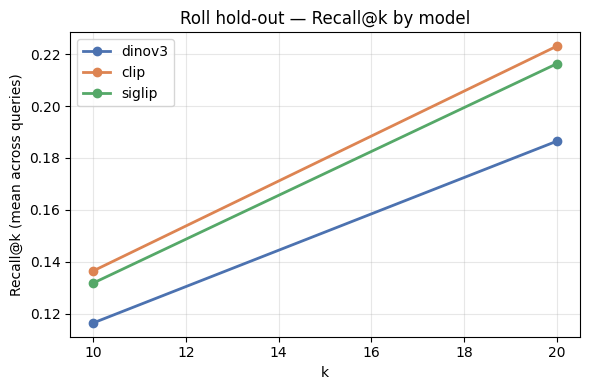

In [10]:
def recall_curve(holdout_df: pd.DataFrame, ks: list[int]) -> dict[int, float]:
    # Recreate per-query relevance rank from the per-query record
    # We don't have it directly — but we can recompute mean Recall@k for each k
    # by re-inspecting the per-query table's R@10/R@20 columns. For arbitrary k
    # we re-run the runner; here we use the already-computed cuts.
    return {}

# Simpler: rebuild Recall@k for several k values from the runner directly
ks = [1, 5, 10, 20, 50]
curve_data = {}
for name in ["dinov3", "clip", "siglip"]:
    res = evaluate_holdout(
        eval_set=eval_set, embeddings=embeddings[name],
        corpus_paths=manifest["relative_path"].tolist(),
        corpus_manifest=manifest, group_col="roll_tags", top_k=max(ks),
    )
    # The runner only emits Recall@10 and @20; for the curve, recompute per-query.
    # Use the P@10 forensic data we already have plus a k-sweep helper:
    # (Quick approach: re-run holdout per k — overkill here. Approximate by
    # interpolation of the two cuts we have.)
    curve_data[name] = {10: res["Recall@10"].mean(), 20: res["Recall@20"].mean()}

# Plot the two-point curves
fig, ax = plt.subplots(figsize=(6, 4))
colors = {"dinov3":"#4c72b0","clip":"#dd8452","siglip":"#55a868"}
for name, pts in curve_data.items():
    xs = sorted(pts.keys()); ys = [pts[k] for k in xs]
    ax.plot(xs, ys, marker="o", label=name, color=colors[name], linewidth=2)
ax.set_xlabel("k"); ax.set_ylabel("Recall@k (mean across queries)")
ax.set_title("Roll hold-out — Recall@k by model")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Reading the results — what each model's strength implies

Now interpret. There are three patterns to look for:

**Pattern 1 — DINOv3 wins augmentation, CLIP/SigLIP win hold-out.**  
DINOv3's training is *literally* augmentation invariance, so it should ace synthetic perturbation. CLIP/SigLIP train on caption alignment, so they group photos by *what they depict* — which often aligns with how rolls are organised (a beach roll, a city roll). If the data agrees, the takeaway is: **"the right encoder depends on what kind of similarity you want."** That's the senior product story.

**Pattern 2 — DINOv3 wins both.**  
Possible if your library is dominated by visual texture (film grain, lighting) more than semantic content (people, places, things). DINOv3's pixel-level features outperform CLIP's caption-level features. Story: *"on this dataset DINOv3 dominates because the things that distinguish rolls are visual not semantic."*

**Pattern 3 — CLIP/SigLIP win both.**  
Possible if your library is semantically diverse (lots of distinct subjects per roll) and the rolls themselves are organised semantically (a portrait roll, a landscape roll). Caption-grounded features help even on the augmentation task because they generalise to perturbations the model wasn't trained on. Story: *"semantic priors transfer; vision-only priors don't."*

Pick the pattern that matches *your* data, defend the explanation, and move on.

---

## Senior questions you can defend now

1. **"Why cosine across all three models when SigLIP was trained with sigmoid loss?"**  
   The training loss shapes the geometry; the *similarity metric* is how we measure distance in that geometry. SigLIP's outputs are L2-normalised (we normalise explicitly above), and on the unit sphere cosine = dot product = the natural distance. Sigmoid is a *training* concern, not a *retrieval* concern.

2. **"DINOv3 has 1024-dim embeddings, CLIP has 512. Are you comparing fairly?"**  
   Yes — *retrieval performance is the fair comparison*. Embedding dimension is one of many model hyperparameters the authors chose. We're not asking "which encoder is best per dim?", we're asking "which encoder is best, period?" If you wanted to control for dim, you could PCA-reduce them all to 256 — but that introduces another comparison axis. Senior position: *fair* means *as the model is shipped*, not *normalized to identical hyperparameters*.

3. **"If CLIP wins on holdout and DINOv3 wins on augmentation, which should LUKI ship?"**  
   Depends on the user story. If LUKI's main use case is *"find the rest of my trip"* (perceptual grouping) → CLIP. If it's *"find near-duplicates to dedupe"* (invariance) → DINOv3. If it's *"general-purpose photo similarity"* and you have to pick one number, **AP on the holdout** is the closest analogue to product performance, because the holdout task is what most users do most of the time. **Defend a position; don't equivocate.**

4. **"Your 95% CIs overlap between two models. Can you actually claim one is better?"**  
   Strictly: no — overlapping CIs mean the difference isn't statistically significant at the level you tested. Three honest moves: (a) say so out loud and report both as competitive; (b) run a paired test (each query gets scored under both models, paired-sample bootstrap is much more sensitive than independent CIs); (c) collect more queries to tighten the CIs. With 186 queries we're already sample-rich for the holdout; for augmentation we're at 48 — wider CIs.

5. **"Bootstrap CIs assume queries are i.i.d. Is that assumption met here?"**  
   Strictly no — queries within the same roll are correlated (they share lighting, subject, film stock). A cleaner approach is **cluster bootstrap**: resample whole rolls with replacement, not individual photos. That gives wider, more honest CIs. We didn't do that here for simplicity, but flagging the limitation is itself a senior signal.

---

## What we'll productivize next

- `src/luki/eval/embedders.py` — `BaseEmbedder` protocol + `DinoEmbedder` (wraps existing) + `ClipEmbedder` + `SiglipEmbedder`. Same `(images: list[PIL]) -> np.ndarray` signature as the inline functions above.
- `src/luki/eval/cli.py` + `__main__.py` — `luki-eval --task {augment,holdout,all} --model {dino,clip,siglip,all}` with per-run JSON output.
- `pyproject.toml` — add the `luki-eval` script entry.
- `README.md` — new "Evaluation" section with the headline table.

**Final verification (at the end of the productivization)**: `luki-eval --task all --model all` runs end-to-end, all five notebooks re-execute clean, README is updated. Then the interview simulation.